# 1. Project Objective

# AI Job Market 2025–2026
## Analyzing Salaries, Demand, Skills & Career Trends

### Business Question

What factors determine salary and demand in the AI job market,
and what skills are most valuable for aspiring AI professionals?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Dataset overview

In [2]:
df = pd.read_csv("ai_jobs_market_2025_2026.csv")

pd.set_option("display.max_columns", None)

df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [3]:
df.shape

(1500, 25)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   str    
 1   job_title              1500 non-null   str    
 2   job_category           1500 non-null   str    
 3   experience_level       1500 non-null   str    
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   str    
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   str    
 10  country                1500 non-null   str    
 11  remote_work            1500 non-null   str    
 12  company_size           1500 non-null   str    
 13  industry               1500 non-null   str    
 14  required_skills        1500 non-null   str    
 15  ai_salary_premi

In [5]:
# Basic numerical summary

df.describe()

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,135448.666667,257537.333333,10.858200,87.523333,31.116333,7.897333,2025.584000,3.968000,0.496667,0.754000,0.218000
std,2.675216,66506.822013,24448.950878,39852.822207,4.029742,8.026315,22.046343,1.102846,0.493058,3.270388,0.500156,0.430822,0.413025
min,1.000000,90000.000000,90000.000000,180000.000000,3.000000,68.000000,5.000000,6.000000,2025.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,144750.000000,120000.000000,218000.000000,8.200000,82.000000,15.375000,6.900000,2025.000000,2.000000,0.000000,1.000000,0.000000
50%,6.000000,180000.000000,140000.000000,270000.000000,10.500000,89.000000,23.400000,7.900000,2026.000000,3.000000,0.000000,1.000000,0.000000
75%,8.000000,236250.000000,155000.000000,290000.000000,14.200000,95.000000,42.700000,8.900000,2026.000000,5.000000,1.000000,1.000000,0.000000
max,15.000000,384000.000000,180000.000000,320000.000000,18.000000,98.000000,87.800000,9.800000,2026.000000,12.000000,1.000000,1.000000,1.000000


# 3. Data Cleaning & Preparation

In [6]:
# Duplicate rows

df.duplicated().sum()

np.int64(0)

In [7]:
# Missing values

df.isnull().sum()

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

In [8]:
categorical_columns = [
    'job_title',
    'job_category',
    'experience_level',
    'education_required',
    'country',
    'remote_work',
    'company_size',
    'industry',
    'salary_tier'
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- job_title ---
job_title
LLM Engineer                75
Robotics Engineer (AI)      74
Prompt Engineer             71
Generative AI Engineer      71
AI Product Manager          70
Multimodal AI Engineer      67
Senior Data Scientist       66
AI Compliance Manager       66
Senior ML Engineer          64
AI Engineer                 64
AI Business Analyst         62
Data Scientist              61
Deep Learning Engineer      58
AI Agent Developer          57
AI Ethics Officer           56
NLP Engineer                55
ML Engineer                 55
AI Infrastructure Eng       55
RAG Engineer                53
AI Solutions Architect      52
Data Engineer (AI)          51
MLOps Engineer              51
AI Security Engineer        50
AI Research Scientist       50
Computer Vision Engineer    46
Name: count, dtype: int64

--- job_category ---
job_category
AI Engineering      736
Data Science        127
Governance          122
Robotics             74
Product              70
Business       

In [9]:
df['annual_salary_usd'].describe()

count      1500.000000
mean     194892.000000
std       66506.822013
min       90000.000000
25%      144750.000000
50%      180000.000000
75%      236250.000000
max      384000.000000
Name: annual_salary_usd, dtype: float64

# 4. Salary Analysis

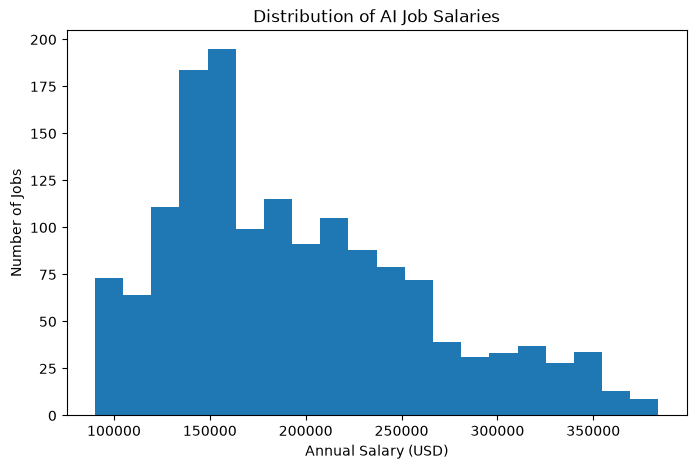

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df['annual_salary_usd'], bins=20)

plt.xlabel("Annual Salary (USD)")
plt.ylabel("Number of Jobs")
plt.title("Distribution of AI Job Salaries")

plt.show()

In [11]:
df['annual_salary_usd'].median()

np.float64(180000.0)

In [12]:
df['annual_salary_usd'].mean()

np.float64(194892.0)

In [13]:
# “How does years of experience relate to annual salary in the AI job market?”

experience_salary = df.groupby('experience_level')['annual_salary_usd'].agg(
    ['count', 'mean', 'median']
)

experience_salary

,count,mean,median
experience_level,,,
Entry (0-2 yrs),385,150038.961039,145000.0
Lead (10+ yrs),381,240055.118110,238000.0
Mid (3-5 yrs),370,175983.783784,162000.0
Senior (6-9 yrs),364,214280.219780,208000.0


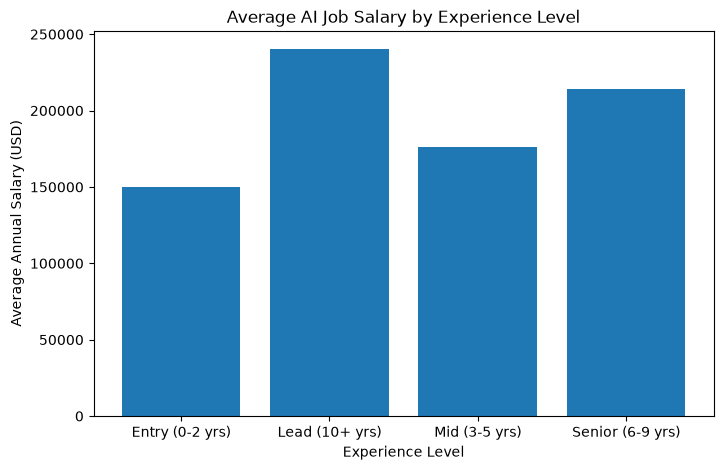

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    experience_salary.index,
    experience_salary['mean']
)

plt.xlabel("Experience Level")
plt.ylabel("Average Annual Salary (USD)")
plt.title("Average AI Job Salary by Experience Level")

plt.show()

<Figure size 800x500 with 0 Axes>

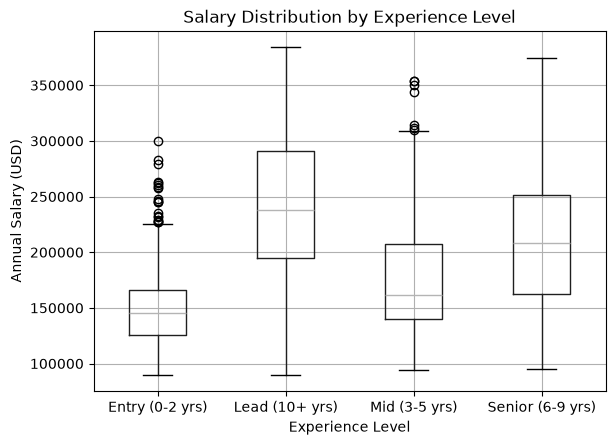

In [15]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='annual_salary_usd',
    by='experience_level'
)

plt.xlabel("Experience Level")
plt.ylabel("Annual Salary (USD)")
plt.title("Salary Distribution by Experience Level")

plt.suptitle("")

plt.show()

In [16]:
df[['years_of_experience', 'annual_salary_usd']].corr()

,years_of_experience,annual_salary_usd
years_of_experience,1.000000,0.078643
annual_salary_usd,0.078643,1.000000


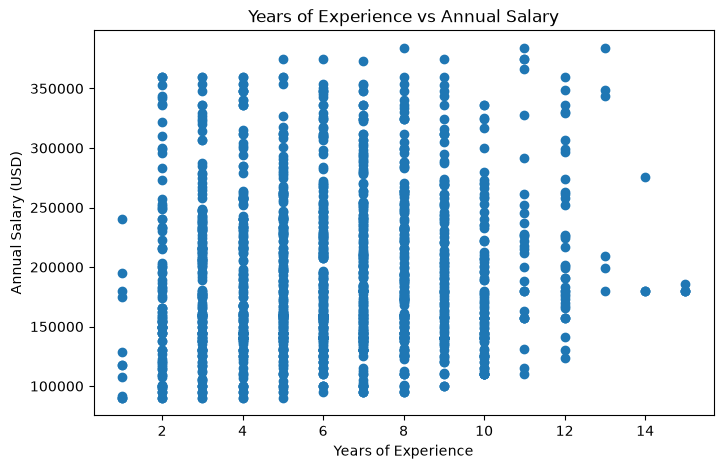

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['years_of_experience'],
    df['annual_salary_usd']
)

plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary (USD)")
plt.title("Years of Experience vs Annual Salary")

plt.show()

In [18]:
year_salary = df.groupby('years_of_experience')['annual_salary_usd'].agg(
    ['count', 'mean', 'median']
)

year_salary

,count,mean,median
years_of_experience,,,
1,12,135416.666667,118000.0
2,99,184202.020202,160000.0
3,166,191632.530120,178000.0
4,166,195548.192771,179000.0
5,178,191025.842697,173000.0
6,208,196006.730769,180000.0
7,197,199464.974619,185000.0
8,174,196242.528736,179500.0
9,120,199996.666667,186500.0


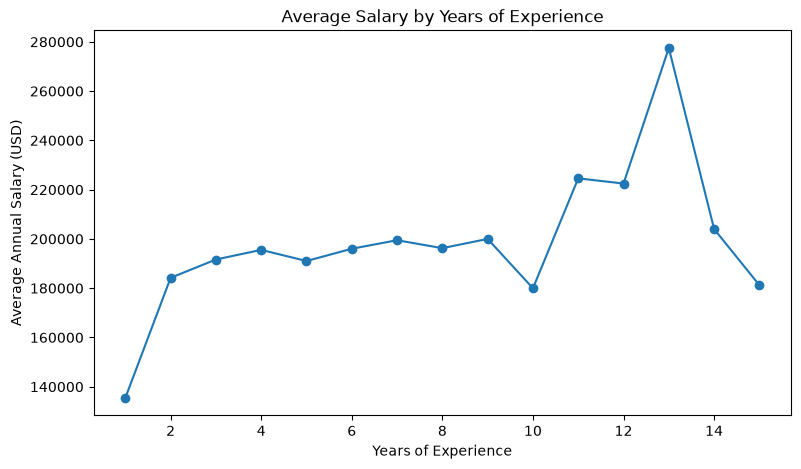

In [19]:
plt.figure(figsize=(9, 5))

plt.plot(
    year_salary.index,
    year_salary['mean'],
    marker='o'
)

plt.xlabel("Years of Experience")
plt.ylabel("Average Annual Salary (USD)")
plt.title("Average Salary by Years of Experience")

plt.show()

In [20]:
category_salary = df.groupby('job_category')['annual_salary_usd'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

category_salary

,count,mean,median
job_category,,,
Architecture,52,251576.923077,238000.0
AI Engineering,736,207982.336957,194500.0
Infrastructure,55,203527.272727,196000.0
Security,50,200400.000000,194500.0
ML Operations,51,199215.686275,189000.0
Product,70,194571.428571,185000.0
Research,50,192280.000000,183000.0
Data Science,127,181275.590551,162000.0
Data Engineering,51,176156.862745,160000.0


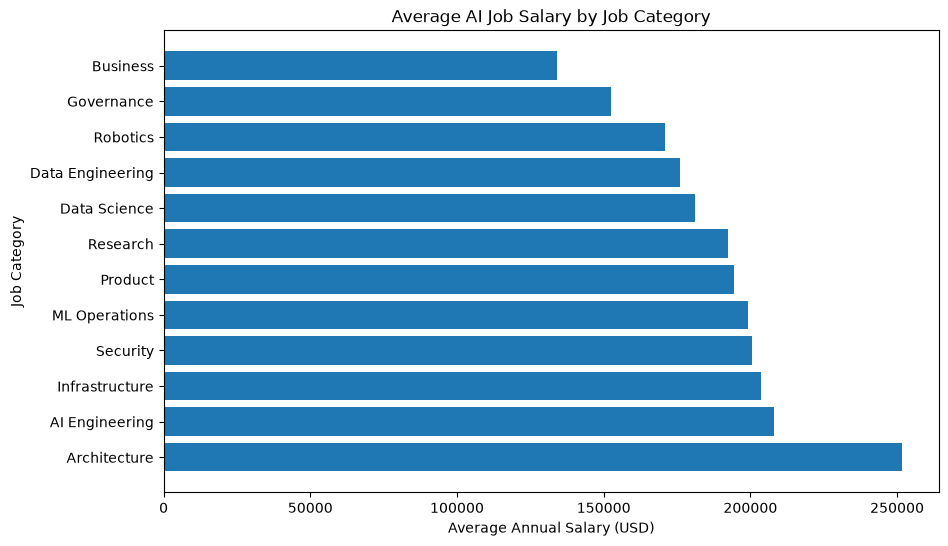

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    category_salary.index,
    category_salary['mean']
)

plt.xlabel("Average Annual Salary (USD)")
plt.ylabel("Job Category")
plt.title("Average AI Job Salary by Job Category")

plt.show()

In [22]:
# pivot table showing average salary for each job category across experience levels.

category_experience_salary = df.pivot_table(
    values='annual_salary_usd',
    index='job_category',
    columns='experience_level',
    aggfunc='mean'
)

category_experience_salary

experience_level,Entry (0-2 yrs),Lead (10+ yrs),Mid (3-5 yrs),Senior (6-9 yrs)
job_category,,,,
AI Engineering,155273.224044,252191.752577,187787.356322,232755.675676
Architecture,194100.000000,326500.000000,246750.000000,290125.000000
Business,101047.619048,188250.000000,121562.500000,153153.846154
Data Engineering,139235.294118,210153.846154,168375.000000,195230.769231
Data Science,158172.413793,215296.969697,157774.193548,189388.235294
Governance,124090.909091,197400.000000,126133.333333,170382.352941
Infrastructure,170375.000000,251357.142857,179388.888889,205533.333333
ML Operations,143800.000000,256454.545455,177875.000000,218214.285714
Product,158100.000000,246181.818182,172923.076923,186266.666667


# “Salary varies substantially by both job category and experience level. Architecture has the highest average salary across all experience levels in this dataset, while AI Engineering combines relatively high salaries with a much larger number of job postings. This indicates that job specialization may be an important factor alongside experience.”

In [23]:
# “Does higher educational qualification correspond to higher AI job salaries?”

education_salary = df.groupby('education_required')['annual_salary_usd'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

education_salary

,count,mean,median
education_required,,,
PhD,280,213252.142857,204500.0
Master's,316,205805.696203,196500.0
Bachelor's,311,192321.543408,177000.0
Bootcamp/Self-taught,297,187002.020202,176000.0
Associate's,296,176490.540541,160000.0


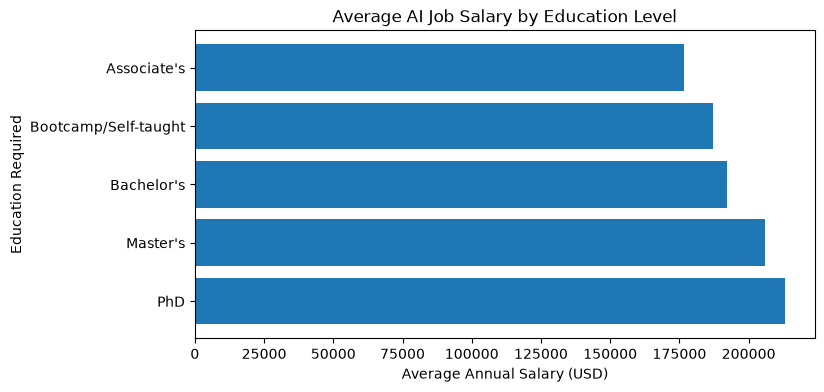

In [24]:
plt.figure(figsize=(8, 4))

plt.barh(
    education_salary.index,
    education_salary['mean']
)

plt.xlabel("Average Annual Salary (USD)")
plt.ylabel("Education Required")
plt.title("Average AI Job Salary by Education Level")

plt.show()

In [25]:
education_experience_salary = df.pivot_table(
    values='annual_salary_usd',
    index='education_required',
    columns='experience_level',
    aggfunc='mean'
)

education_experience_salary

experience_level,Entry (0-2 yrs),Lead (10+ yrs),Mid (3-5 yrs),Senior (6-9 yrs)
education_required,,,,
Associate's,141792.682927,215640.000000,157276.923077,194935.714286
Bachelor's,152554.216867,242272.000000,171075.000000,209501.369863
Bootcamp/Self-taught,137493.150685,229595.294118,162765.625000,207600.000000
Master's,152838.235294,252940.909091,185244.444444,224440.000000
PhD,165139.240506,257347.058824,198816.901408,242725.806452


# “Higher educational requirements are associated with higher salaries across experience levels. PhD-required roles have the highest average salary within every experience group. However, the difference between Bachelor's and Bootcamp/Self-taught roles becomes relatively small at senior levels, suggesting that factors beyond formal education may also influence compensation.”

In [26]:
# Which specific AI jobs pay the most?

title_salary = df.groupby('job_title')['annual_salary_usd'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

title_salary

,count,mean,median
job_title,,,
AI Solutions Architect,52,251576.923077,238000.0
Senior ML Engineer,64,247953.125000,227000.0
LLM Engineer,75,240960.000000,232000.0
AI Agent Developer,57,225649.122807,209000.0
Multimodal AI Engineer,67,221791.044776,209000.0
RAG Engineer,53,218226.415094,215000.0
NLP Engineer,55,210854.545455,180000.0
Computer Vision Engineer,46,209173.913043,201000.0
Generative AI Engineer,71,206760.563380,177000.0


In [27]:
title_experience_salary = df.pivot_table(
    values='annual_salary_usd',
    index='job_title',
    columns='experience_level',
    aggfunc='mean'
)

title_experience_salary = title_experience_salary.loc[
    title_experience_salary.mean(axis=1).sort_values(ascending=False).index
]

title_experience_salary

experience_level,Entry (0-2 yrs),Lead (10+ yrs),Mid (3-5 yrs),Senior (6-9 yrs)
job_title,,,,
AI Solutions Architect,194100.000000,326500.000000,246750.000000,290125.000000
Senior ML Engineer,219555.555556,311100.000000,210235.294118,253300.000000
LLM Engineer,177857.142857,281350.000000,220500.000000,275636.363636
AI Agent Developer,167266.666667,296153.846154,213545.454545,230777.777778
Multimodal AI Engineer,180375.000000,276705.882353,189368.421053,244800.000000
RAG Engineer,151176.470588,273263.157895,202000.000000,248250.000000
Generative AI Engineer,156777.777778,268600.000000,189857.142857,226000.000000
Computer Vision Engineer,161538.461538,254909.090909,183400.000000,240333.333333
NLP Engineer,152916.666667,255000.000000,189666.666667,236416.666667


# “Job title remains strongly associated with salary even within comparable experience levels. Specialized roles such as AI Solutions Architect, LLM Engineer and Senior ML Engineer show substantially higher salaries than business-oriented roles, suggesting that specialization is an important factor in AI compensation.”

In [28]:
# Does location affect AI salaries?

country_salary = df.groupby('country')['annual_salary_usd'].agg(
    count='count',
    mean='mean',
    median='median'
)

country_salary = country_salary.drop('Global')

country_salary = country_salary.sort_values('mean', ascending=False)

country_salary

,count,mean,median
country,,,
USA,515,226189.902913,219000.0
UAE,62,194225.806452,186500.0
Switzerland,76,190592.105263,167500.0
Australia,78,188000.000000,180500.0
France,66,183151.515152,160000.0
Singapore,71,181830.985915,180000.0
Germany,81,181180.246914,173000.0
UK,90,180644.444444,167500.0
Canada,85,180588.235294,159000.0


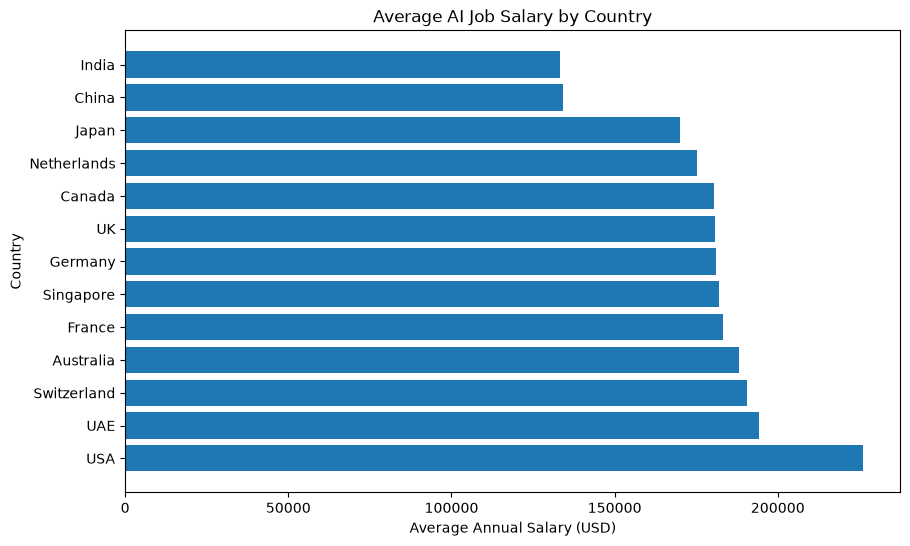

In [29]:
plt.figure(figsize=(10, 6))

plt.barh(
    country_salary.index,
    country_salary['mean']
)

plt.xlabel("Average Annual Salary (USD)")
plt.ylabel("Country")
plt.title("Average AI Job Salary by Country")

plt.show()

In [30]:
country_experience_salary = df.pivot_table(
    values='annual_salary_usd',
    index='country',
    columns='experience_level',
    aggfunc='mean'
)

country_experience_salary = country_experience_salary.drop('Global')

country_experience_salary

experience_level,Entry (0-2 yrs),Lead (10+ yrs),Mid (3-5 yrs),Senior (6-9 yrs)
country,,,,
Australia,131400.000000,227774.193548,152904.761905,192375.000000
Canada,137208.333333,242086.956522,154736.842105,186789.473684
China,128000.000000,134724.137931,136826.086957,135095.238095
France,134833.333333,260736.842105,159375.000000,192571.428571
Germany,135000.000000,213523.076923,156954.545455,206529.411765
India,127916.666667,129375.000000,137083.333333,137529.411765
Japan,136760.000000,236266.666667,150222.222222,181277.777778
Netherlands,147444.444444,232500.000000,158500.000000,183545.454545
Singapore,139950.000000,232375.000000,170823.529412,193833.333333


# “Geographic differences in salary persist across experience levels. The USA shows the highest average salaries among most experience groups and a substantial increase from entry to lead positions, while India and China show comparatively lower and flatter salary patterns across experience levels.”

In [31]:
# Remote Work vs Salary

remote_salary = df.groupby('remote_work')['annual_salary_usd'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

remote_salary

,count,mean,median
remote_work,,,
Fully Remote,445,197967.191011,181000.0
On-site,369,195268.834688,180000.0
Hybrid,686,192694.460641,179000.0


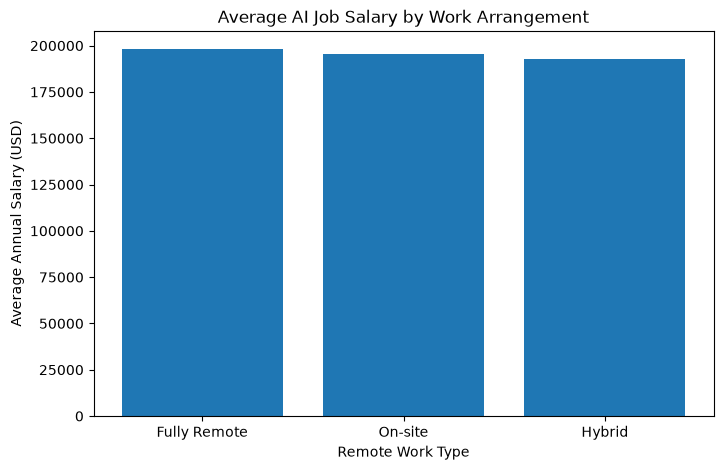

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    remote_salary.index,
    remote_salary['mean']
)

plt.xlabel("Remote Work Type")
plt.ylabel("Average Annual Salary (USD)")
plt.title("Average AI Job Salary by Work Arrangement")

plt.show()

# “Fully remote roles have the highest average salary in the dataset, but the difference between remote, on-site, and hybrid positions is relatively small. This suggests that work arrangement has a weaker association with salary than factors such as job specialization and location.”

# 5. Demand Analysis

In [33]:
# Job Category vs Demand
# Which AI job categories have the highest demand?

category_demand = df.groupby('job_category')['demand_score'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

category_demand

,count,mean,median
job_category,,,
ML Operations,51,93.000000,93.0
AI Engineering,736,92.566576,95.0
Data Science,127,90.960630,90.0
Data Engineering,51,88.000000,88.0
Research,50,88.000000,88.0
Infrastructure,55,85.000000,85.0
Product,70,85.000000,85.0
Architecture,52,84.000000,84.0
Security,50,80.000000,80.0


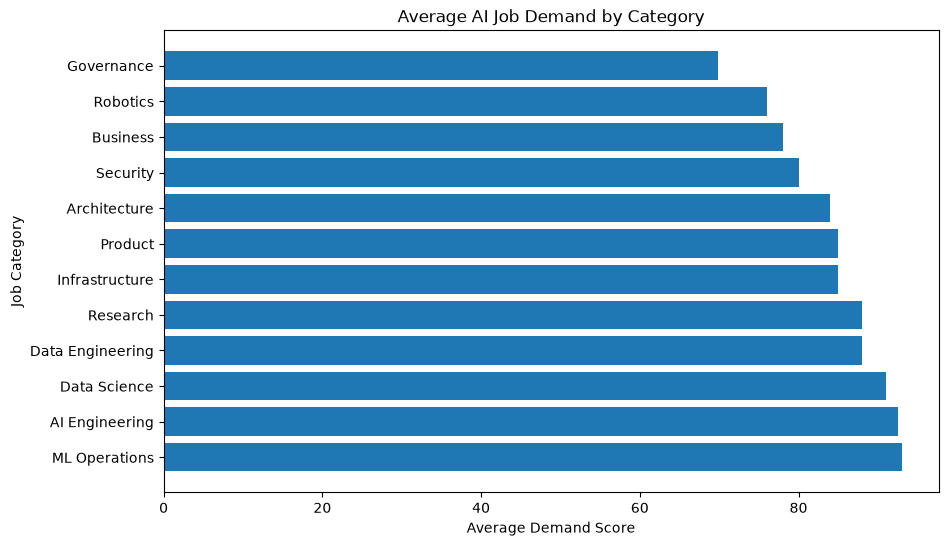

In [34]:
plt.figure(figsize=(10, 6))

plt.barh(
    category_demand.index,
    category_demand['mean']
)

plt.xlabel("Average Demand Score")
plt.ylabel("Job Category")
plt.title("Average AI Job Demand by Category")

plt.show()

In [35]:
# Which specific AI job titles have the highest demand scores?

title_demand = df.groupby('job_title')['demand_score'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

title_demand

,count,mean,median
job_title,,,
LLM Engineer,75,98.0,98.0
ML Engineer,55,97.0,97.0
Senior ML Engineer,64,96.0,96.0
AI Agent Developer,57,96.0,96.0
AI Engineer,64,95.0,95.0
Generative AI Engineer,71,95.0,95.0
RAG Engineer,53,94.0,94.0
MLOps Engineer,51,93.0,93.0
Data Scientist,61,92.0,92.0


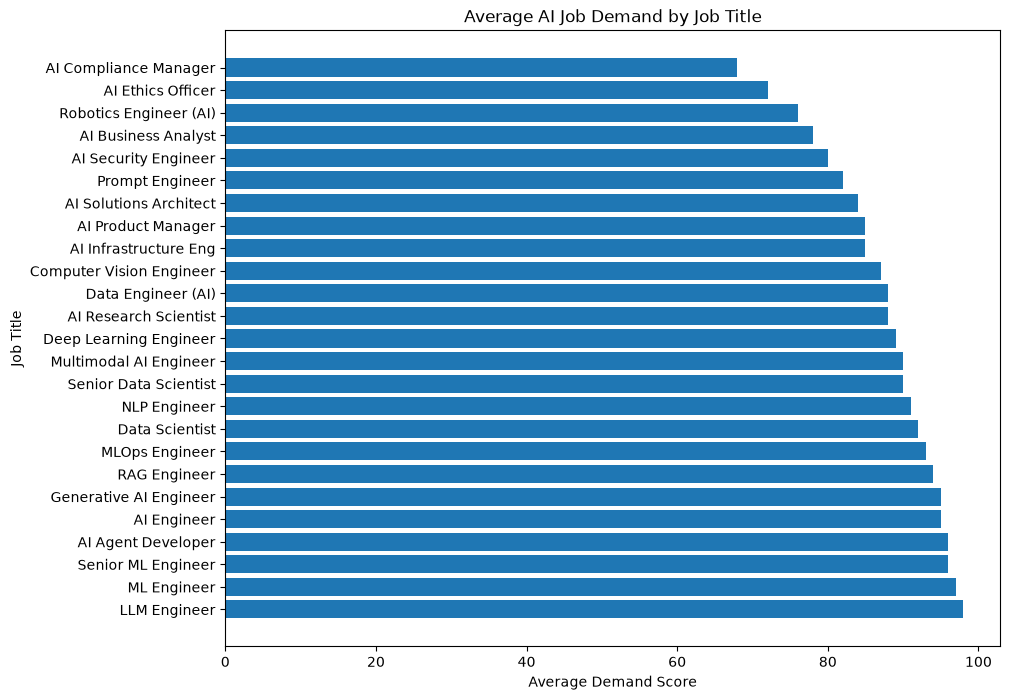

In [36]:
plt.figure(figsize=(10, 8))

plt.barh(
    title_demand.index,
    title_demand['mean']
)

plt.xlabel("Average Demand Score")
plt.ylabel("Job Title")
plt.title("Average AI Job Demand by Job Title")

plt.show()

In [37]:
# Which AI job categories are experiencing the strongest year-over-year demand growth?

category_growth = df.groupby('job_category')['demand_growth_yoy_pct'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

category_growth

,count,mean,median
job_category,,,
ML Operations,51,52.819608,55.40
AI Engineering,736,40.247826,33.70
Data Science,127,31.503937,23.20
Data Engineering,51,19.652941,20.10
Infrastructure,55,18.398182,18.60
Robotics,74,18.067568,18.50
Architecture,52,18.032692,16.65
Research,50,17.478000,17.80
Product,70,17.311429,16.80


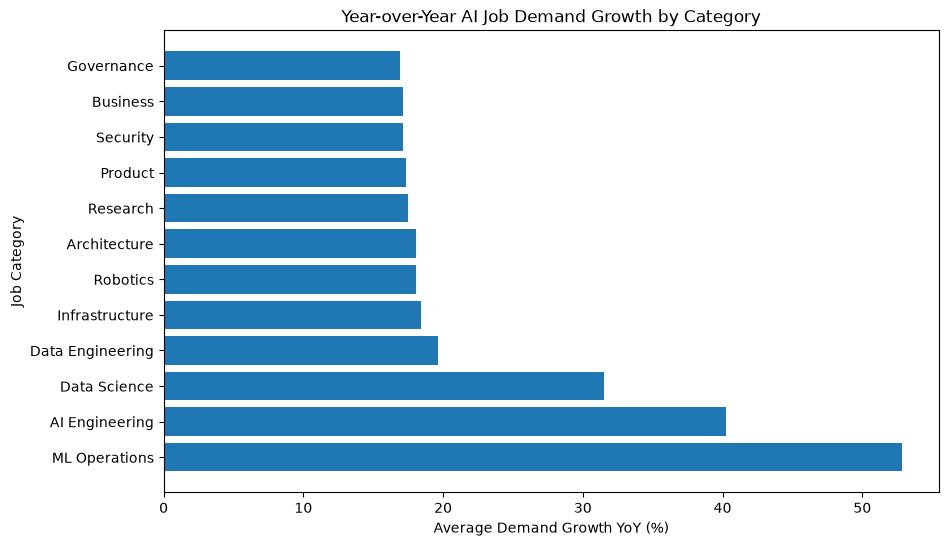

In [38]:
plt.figure(figsize=(10, 6))

plt.barh(
    category_growth.index,
    category_growth['mean']
)

plt.xlabel("Average Demand Growth YoY (%)")
plt.ylabel("Job Category")
plt.title("Year-over-Year AI Job Demand Growth by Category")

plt.show()

# ML Operations has the highest average year-over-year demand growth at 52.82%, followed by AI Engineering at 40.25% and Data Science at 31.50%. AI Engineering is particularly notable because its high growth is supported by a much larger number of job postings. Most other categories show considerably lower growth rates of around 17–20%.

# 6. Skills Analysis

In [39]:
skills = df['required_skills'].str.split('|').explode().str.strip()

skill_counts = skills.value_counts()

skill_counts.head(20)

required_skills
Python                 942
SQL                    452
Cloud                  429
Leadership             380
Communication          378
Research               376
Agile                  351
Statistics             350
Linux                  320
Problem Solving        314
PyTorch                302
Git                    295
Fine-tuning            164
LLMs                   125
Kubernetes             123
CUDA                   117
Documentation          108
LLM APIs               103
Distributed Systems     99
APIs                    98
Name: count, dtype: int64

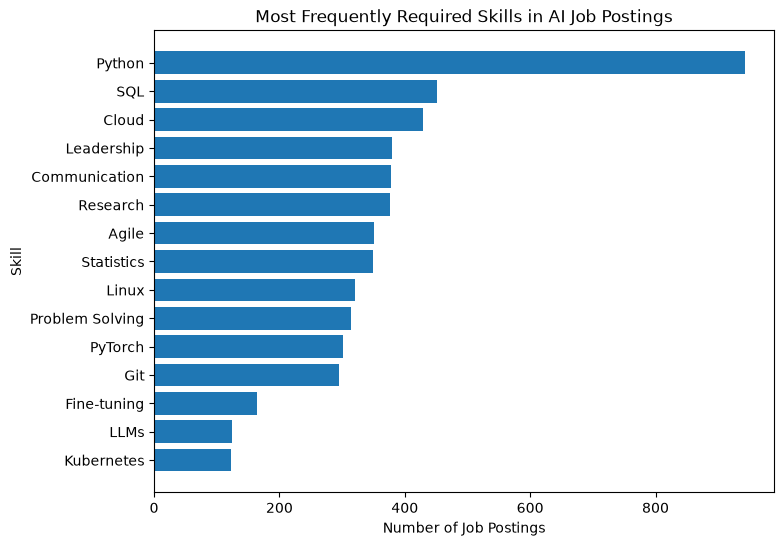

In [40]:
top_skills = skill_counts.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top_skills.index[::-1],
    top_skills.values[::-1]
)

plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.title("Most Frequently Required Skills in AI Job Postings")

plt.show()

In [41]:
# Skills vs Salary

skill_salary = df.copy()

skill_salary['skill_list'] = skill_salary['required_skills'].str.split('|')

skill_salary = skill_salary.explode('skill_list')

skill_salary['skill_list'] = skill_salary['skill_list'].str.strip()

skill_salary = skill_salary.groupby('skill_list')['annual_salary_usd'].agg(
    ['count', 'mean', 'median']
).sort_values('mean', ascending=False)

skill_salary.head(20)

,count,mean,median
skill_list,,,
System Design,96,248947.916667,227000.0
Prompt Engineering,55,246381.818182,240000.0
LLM Fine-tuning,42,242633.333333,226500.0
RAG,63,241190.476190,238000.0
Enterprise Architecture,31,240612.903226,215000.0
MLOps,88,230352.272727,218000.0
Tool Use,44,228568.181818,213000.0
LangChain,77,227987.012987,217000.0
Fine-tuning,164,226628.048780,206500.0


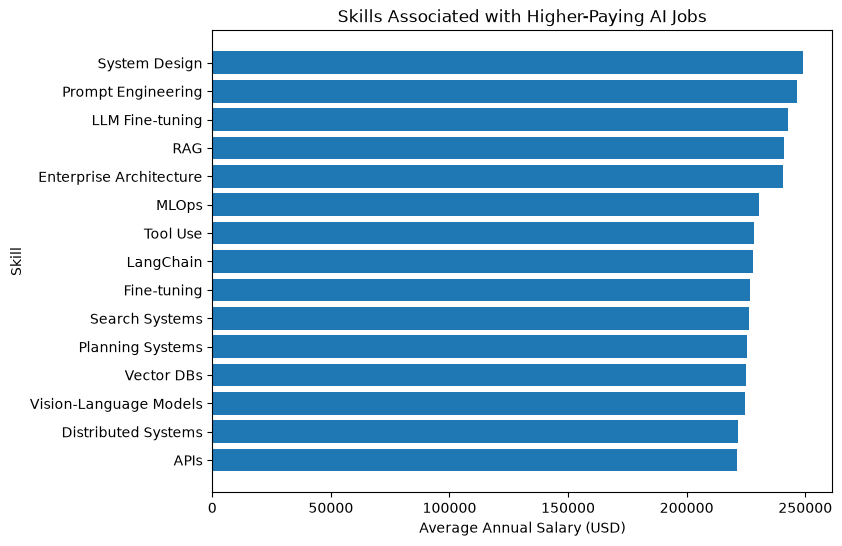

In [42]:
top_salary_skills = skill_salary.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top_salary_skills.index[::-1],
    top_salary_skills['mean'][::-1]
)

plt.xlabel("Average Annual Salary (USD)")
plt.ylabel("Skill")
plt.title("Skills Associated with Higher-Paying AI Jobs")

plt.show()

# Advanced AI engineering skills such as System Design, Prompt Engineering, LLM Fine-tuning, RAG, MLOps, and LangChain are associated with higher average salaries in the dataset. However, these relationships should be interpreted as associations rather than causal effects, since salary also depends on factors such as role, experience, and location.

# 7. LLM Role Analysis

In [43]:
# LLM vs Non-LLM Roles
llm_analysis = df.groupby('is_llm_role').agg(
    job_count=('job_id', 'count'),
    avg_salary=('annual_salary_usd', 'mean'),
    median_salary=('annual_salary_usd', 'median'),
    avg_demand=('demand_score', 'mean'),
    avg_growth=('demand_growth_yoy_pct', 'mean')
)

llm_analysis

,job_count,avg_salary,median_salary,avg_demand,avg_growth
is_llm_role,,,,,
0,1173,191308.610401,180000.0,86.030691,27.610997
1,327,207746.177370,191000.0,92.877676,43.690520


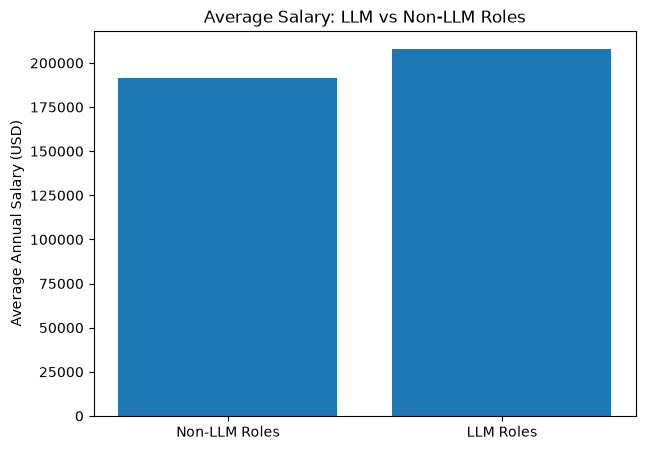

In [44]:
plt.figure(figsize=(7, 5))

plt.bar(
    ['Non-LLM Roles', 'LLM Roles'],
    llm_analysis['avg_salary']
)

plt.ylabel("Average Annual Salary (USD)")
plt.title("Average Salary: LLM vs Non-LLM Roles")

plt.show()

# LLM-focused roles show higher average salary, demand, and year-over-year demand growth than non-LLM roles. LLM roles have an average salary of approximately $207.7K compared with $191.3K for non-LLM roles, while their average demand growth is 43.7% versus 27.6%. This suggests that LLM-related roles are among the stronger-performing segments of the AI job market represented in this dataset.

# 8. Correlation Analysis

In [45]:
# Correlation Heatmap

corr = df[
    [
        'years_of_experience',
        'annual_salary_usd',
        'salary_min_usd',
        'salary_max_usd',
        'ai_salary_premium_pct',
        'demand_score',
        'demand_growth_yoy_pct'
    ]
].corr()

corr

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct
years_of_experience,1.000000,0.078643,0.251169,0.173499,0.138649,-0.096144,-0.121351
annual_salary_usd,0.078643,1.000000,0.421042,0.426631,-0.019829,0.291800,0.142776
salary_min_usd,0.251169,0.421042,1.000000,0.742550,-0.076302,0.524296,0.182718
salary_max_usd,0.173499,0.426631,0.742550,1.000000,0.081615,0.602882,0.299010
ai_salary_premium_pct,0.138649,-0.019829,-0.076302,0.081615,1.000000,-0.189800,-0.084958
demand_score,-0.096144,0.291800,0.524296,0.602882,-0.189800,1.000000,0.565609
demand_growth_yoy_pct,-0.121351,0.142776,0.182718,0.299010,-0.084958,0.565609,1.000000


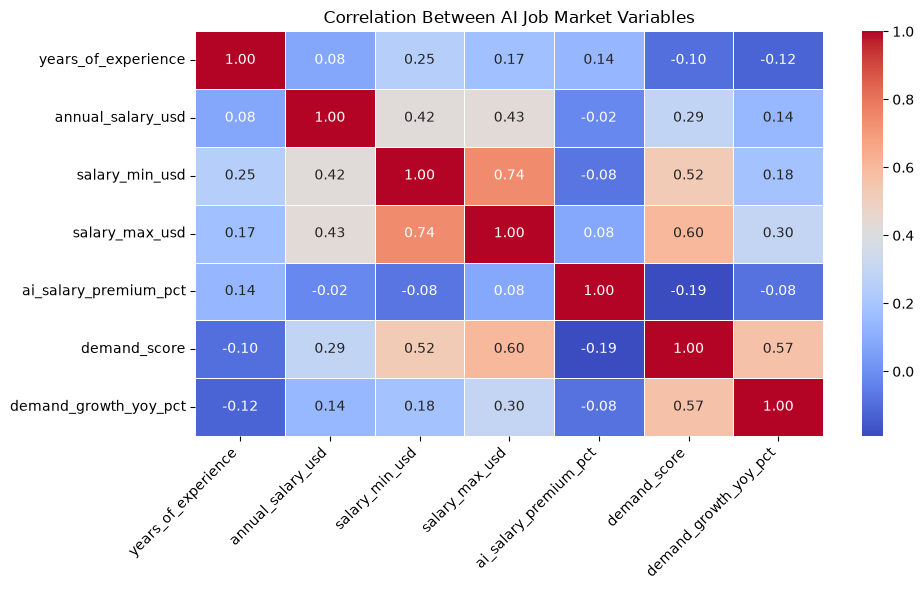

In [46]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between AI Job Market Variables")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 9. Key Findings

### 1. Experience and Salary
Salary generally increases across broad experience levels, with average salary rising from approximately $150K for Entry-level roles to $240K for Lead roles. However, exact years of experience alone show only a weak linear relationship with salary.

### 2. Job Category and Salary
Architecture has the highest average salary among job categories, while AI Engineering combines a relatively high average salary with a much larger number of job postings.

### 3. Job Specialization and Salary
Specialized roles such as AI Solutions Architect, Senior ML Engineer, and LLM Engineer show higher average salaries than several business-oriented AI roles.

### 4. Education and Salary
Roles requiring higher educational qualifications tend to have higher salaries. PhD-required roles have the highest average salary across the experience levels in this dataset.

### 5. Location and Salary
Salary varies substantially by country. The USA records the highest average salary among most experience levels, while India and China show comparatively lower average salaries.

### 6. Demand for AI Roles
ML Operations and AI Engineering have the highest average demand scores among job categories. Data Science also shows strong demand with an average demand score of approximately 91.

### 7. LLM Roles and Growth
LLM-focused roles have higher average salary, demand, and demand growth than non-LLM roles. Their average salary is approximately $207.7K compared with $191.3K for non-LLM roles.

### 8. Skills
Python is the most frequently requested skill, appearing in 942 of the 1,500 job postings. Specialized skills such as System Design, LLM Fine-tuning, RAG, and MLOps are associated with higher average salaries.

# 10. Career Insights

The analysis provides several useful insights for candidates planning a career in AI and Data Science.

### 1. Build Strong Python Fundamentals
Python is the most frequently requested skill in the dataset, appearing in 942 out of 1,500 job postings. Strong Python fundamentals are therefore important for AI and ML careers.

### 2. Develop SQL and Cloud Skills
SQL and Cloud are among the most frequently requested skills. Combining Python with SQL and basic cloud knowledge can improve readiness for data and AI roles.

### 3. Learn Modern AI Technologies
LLM-focused roles show higher demand and faster demand growth than non-LLM roles. Learning concepts such as LLMs, RAG, fine-tuning, and AI APIs can help candidates understand modern AI systems.

### 4. Don't Ignore MLOps and Deployment
ML Operations has the highest category-level demand growth in this dataset. Understanding model deployment, APIs, Docker, cloud platforms, and MLOps concepts can complement machine learning skills.

### 5. Build Both Technical and Soft Skills
Communication, leadership, research, Agile, and problem-solving are also frequently requested alongside technical skills. AI careers therefore require more than programming alone.

### 6. Data Science Remains Relevant
Data Science has a strong demand score and positive demand growth in the dataset. This suggests that data analysis, statistics, machine learning, and data-driven decision-making remain valuable skills.

# Recommendations

### For Job Seekers

- Strengthen Python, SQL, and statistics fundamentals.
- Build practical machine learning and data science projects.
- Learn cloud and basic deployment concepts.
- Explore LLMs, RAG, and fine-tuning.
- Learn Git and MLOps fundamentals.
- Improve communication and problem-solving skills.
- Focus on building projects that demonstrate real-world problem solving rather than only completing tutorials.

### For Employers

- Evaluate candidates based on relevant skills rather than job titles alone.
- Consider demand and growth trends when planning AI hiring.
- Combine technical expertise with communication and problem-solving abilities.
- Use experience, specialization, location, and education together when evaluating compensation.

# 11. Conclusion

This analysis explored the AI job market from 2025–2026 by examining salaries, experience, education, job categories, job titles, locations, demand, skills, and LLM-related roles.

The findings show that salary varies substantially across job specializations, experience levels, education requirements, and countries. Specialized roles such as AI Solutions Architect, Senior ML Engineer, and LLM Engineer are associated with higher salaries.

Demand is particularly strong for AI Engineering, ML Engineering, LLM Engineering, and MLOps-related roles. LLM-focused roles also show higher average salary, demand, and year-over-year demand growth compared with non-LLM roles.

Python is the most frequently requested skill, followed by SQL and Cloud. At the same time, specialized skills such as System Design, RAG, Fine-tuning, and MLOps are associated with higher-paying job postings.

Overall, the analysis suggests that candidates entering the AI field can benefit from combining strong fundamentals in Python, SQL, statistics, and machine learning with modern AI, cloud, and deployment skills. However, the relationships identified in this analysis are associations within the dataset and should not be interpreted as causal relationships.